In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [10]:
df = pd.read_csv("Sales Dataset.csv")
df.head()

,Unnamed: 0,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,2023-11-24,Male,34,Beauty,3,50,150
1,1,2023-02-27,Female,26,Clothing,2,500,1000
2,2,2023-01-13,Male,50,Electronics,1,30,30
3,3,2023-05-21,Male,37,Clothing,1,500,500
4,4,2023-05-06,Male,30,Beauty,2,50,100


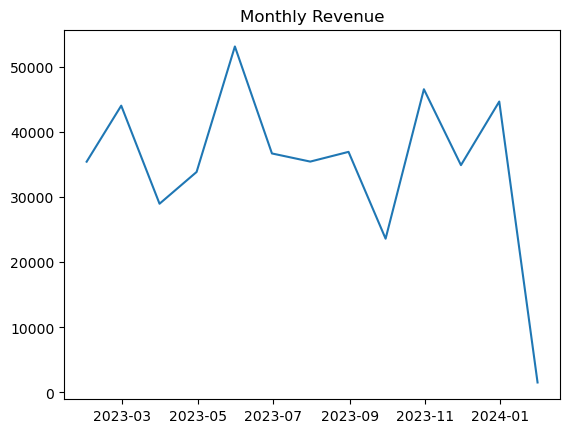

In [47]:
df["Date"] = pd.to_datetime(df["Date"])
monthly = df.groupby(
    pd.Grouper(key="Date", freq="ME")
)["Total Amount"].sum().reset_index()

plt.plot(monthly["Date"], monthly["Total Amount"])
plt.title("Monthly Revenue")
plt.show()

In [35]:
# monthly data
monthly = monthly.reset_index(drop=True)

# create time index
monthly['Month_Number'] = np.arange(len(monthly))

X = monthly[['Month_Number']]
y = monthly['Total Amount']

# train model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [37]:
future_months = np.arange(len(monthly), len(monthly)+6).reshape(-1,1)
future_predictions = model.predict(future_months)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


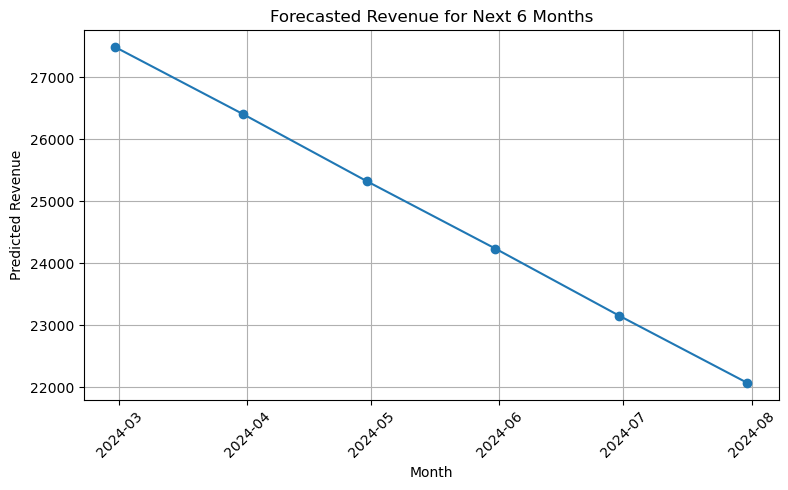

In [45]:
last_date = monthly['Date'].max()
future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=6,
    freq='ME'
)

plt.figure(figsize=(8, 5))
plt.plot(future_dates, future_predictions, marker='o')
plt.title('Forecasted Revenue for Next 6 Months')
plt.xlabel('Month')
plt.ylabel('Predicted Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

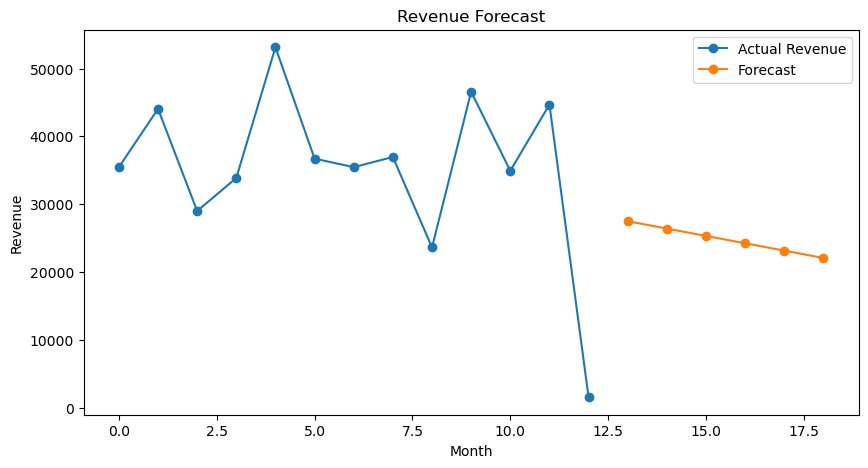

In [39]:
plt.figure(figsize=(10,5))
plt.plot(monthly['Month_Number'], y, marker='o', label='Actual Revenue')
plt.plot(future_months, future_predictions, marker='o', label='Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Revenue Forecast')
plt.legend()
plt.show()